1. Import the Libraries

In [27]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

2. Load Data

In [28]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

train_df = pd.read_csv("../data/nsl-kdd/KDDTrain+.txt", names=col_names)
test_df = pd.read_csv("../data/nsl-kdd/KDDTest-21.txt", names=col_names)

print("---Training Data---")
print(f"Shape: {train_df.shape}")
print("\n---Test Data---")
print(f"Shape: {test_df.shape}")


---Training Data---
Shape: (125973, 43)

---Test Data---
Shape: (11850, 43)


3. Drop unused column

In [29]:
train_df.drop(['difficulty'], axis=1, inplace=True)
test_df.drop(['difficulty'], axis=1, inplace=True)

4. Encode categorical variables

In [30]:
categorical_cols = ['protocol_type', 'service', 'flag']
train_df = pd.get_dummies(train_df, columns=categorical_cols)
test_df = pd.get_dummies(test_df, columns=categorical_cols)

5. Align train and test columns

In [31]:
train_cols = train_df.columns
test_cols = test_df.columns
for c in (set(train_cols) - set(test_cols)):
    test_df[c] = 0
for c in (set(test_cols) - set(train_cols)):
    train_df[c] = 0

# Reorder columns to match
test_df = test_df[train_df.columns]
print(f"Shape of training data after encoding: {train_df.shape}")
print(f"Shape of testing data after encoding: {test_df.shape}")

Shape of training data after encoding: (125973, 123)
Shape of testing data after encoding: (11850, 123)


6. Features & labels

In [32]:
X = train_df.drop(['label'], axis=1)
y = train_df['label']

X_test_final = test_df.drop(['label'], axis=1)
y_test_final = test_df['label']

7. Encode labels into integers (multi-classs)

In [33]:
le = LabelEncoder()
all_labels = pd.concat([train_df['label'], test_df['label']])  # combine labels
le.fit(all_labels)

y = le.transform(train_df['label'])
y_test_final = le.transform(test_df['label'])

8. Scaling

In [34]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_test_final_scaled = scaler.transform(X_test_final)

Class distribution before resampling:
Counter({16: 67343, 14: 41214, 25: 3633, 7: 3599, 20: 2931, 27: 2646, 15: 1493, 1: 956, 32: 892, 34: 890, 19: 201, 4: 53, 2: 30, 35: 20, 8: 18, 6: 11, 23: 10, 9: 9, 3: 8, 12: 7, 18: 4, 17: 3, 30: 2})
Using k_neighbors=1 based on smallest class size=2
Class distribution after resampling:
Counter({16: 67343, 14: 67343, 34: 67343, 7: 67343, 20: 67343, 32: 67343, 15: 67343, 25: 67343, 27: 67343, 19: 67343, 1: 67343, 4: 67343, 3: 67343, 12: 67343, 23: 67343, 2: 67343, 6: 67343, 35: 67343, 18: 67343, 8: 67343, 9: 67343, 30: 67343, 17: 67343})


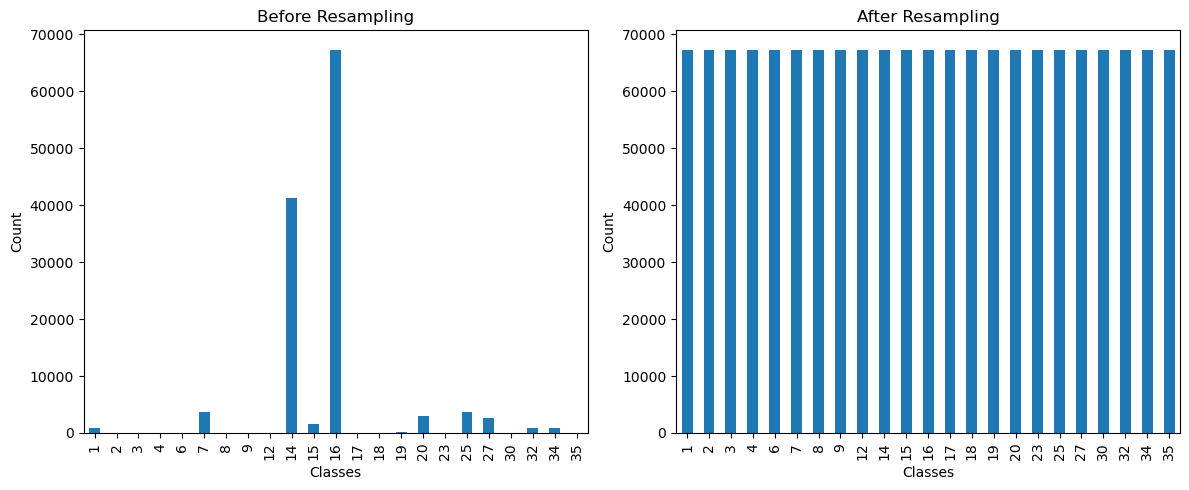

In [35]:
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE, ADASYN
import matplotlib.pyplot as plt

# ----------------------------
# Assume X, y already defined
# ----------------------------

print("Class distribution before resampling:")
print(Counter(y))

# Find the smallest class count
min_class_size = min(Counter(y).values())
k_neighbors = min(5, min_class_size - 1)  # SMOTE requires n_neighbors < class_size

print(f"Using k_neighbors={k_neighbors} based on smallest class size={min_class_size}")

# --- Option 1: Try SMOTE if all classes have >= 2 samples
if min_class_size > 1:
    sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_resampled, y_resampled = sm.fit_resample(X, y)
else:
    # --- Option 2: Fall back to ADASYN if some classes are too tiny
    print("⚠️ Some classes too small for SMOTE. Using ADASYN instead.")
    ada = ADASYN(random_state=42, n_neighbors=1)
    X_resampled, y_resampled = ada.fit_resample(X, y)

print("Class distribution after resampling:")
print(Counter(y_resampled))

# ----------------------------
# Plot class distribution
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before resampling
pd.Series(y).value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title("Before Resampling")
axes[0].set_xlabel("Classes")
axes[0].set_ylabel("Count")

# After resampling
pd.Series(y_resampled).value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title("After Resampling")
axes[1].set_xlabel("Classes")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


9. Train/Validation Split

In [36]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

10. Models

In [37]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Linear SVM": LinearSVC(random_state=42, max_iter=2000)
}

11. Training & Evaluation


===== Logistic Regression =====


c:\Users\khush\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in l

Validation Accuracy: 0.8378314018098111
Validation Report:
                  precision    recall  f1-score   support

           back       0.00      0.00      0.00        96
buffer_overflow       0.00      0.00      0.00         3
      ftp_write       0.00      0.00      0.00         1
   guess_passwd       0.00      0.00      0.00         5
           imap       0.00      0.00      0.00         1
        ipsweep       0.00      0.00      0.00       360
           land       0.00      0.00      0.00         2
     loadmodule       0.00      0.00      0.00         1
       multihop       0.00      0.00      0.00         1
        neptune       0.80      1.00      0.89      4122
           nmap       0.00      0.00      0.00       149
         normal       0.87      0.95      0.91      6735
            pod       0.00      0.00      0.00        20
      portsweep       0.63      0.24      0.35       293
        rootkit       0.00      0.00      0.00         1
          satan       0.00 

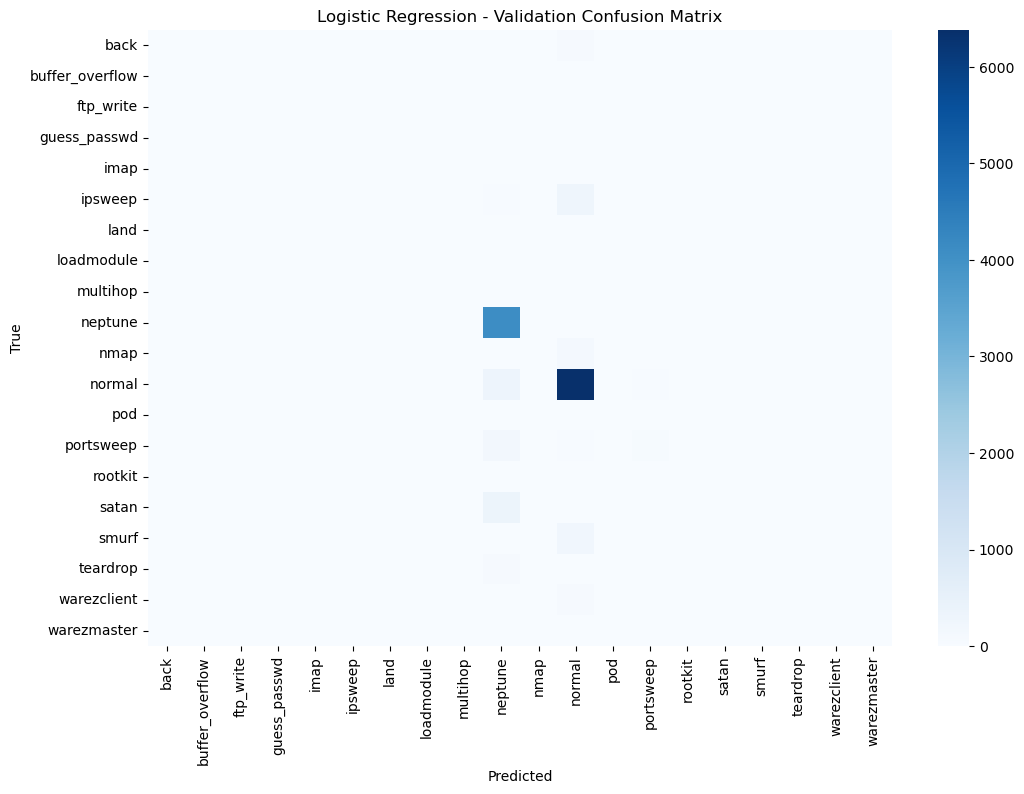

c:\Users\khush\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no p

Test Accuracy: 0.23392405063291138
Test Report:
                  precision    recall  f1-score   support

        apache2       0.00      0.00      0.00       737
           back       0.00      0.00      0.00       359
buffer_overflow       0.00      0.00      0.00        20
      ftp_write       0.00      0.00      0.00         3
   guess_passwd       0.00      0.00      0.00      1231
     httptunnel       0.00      0.00      0.00       133
           imap       0.00      0.00      0.00         1
        ipsweep       0.00      0.00      0.00       141
           land       0.00      0.00      0.00         7
     loadmodule       0.00      0.00      0.00         2
       mailbomb       0.00      0.00      0.00       293
          mscan       0.00      0.00      0.00       996
       multihop       0.00      0.00      0.00        18
          named       0.00      0.00      0.00        17
        neptune       0.27      0.97      0.43      1579
           nmap       0.00      0.00  

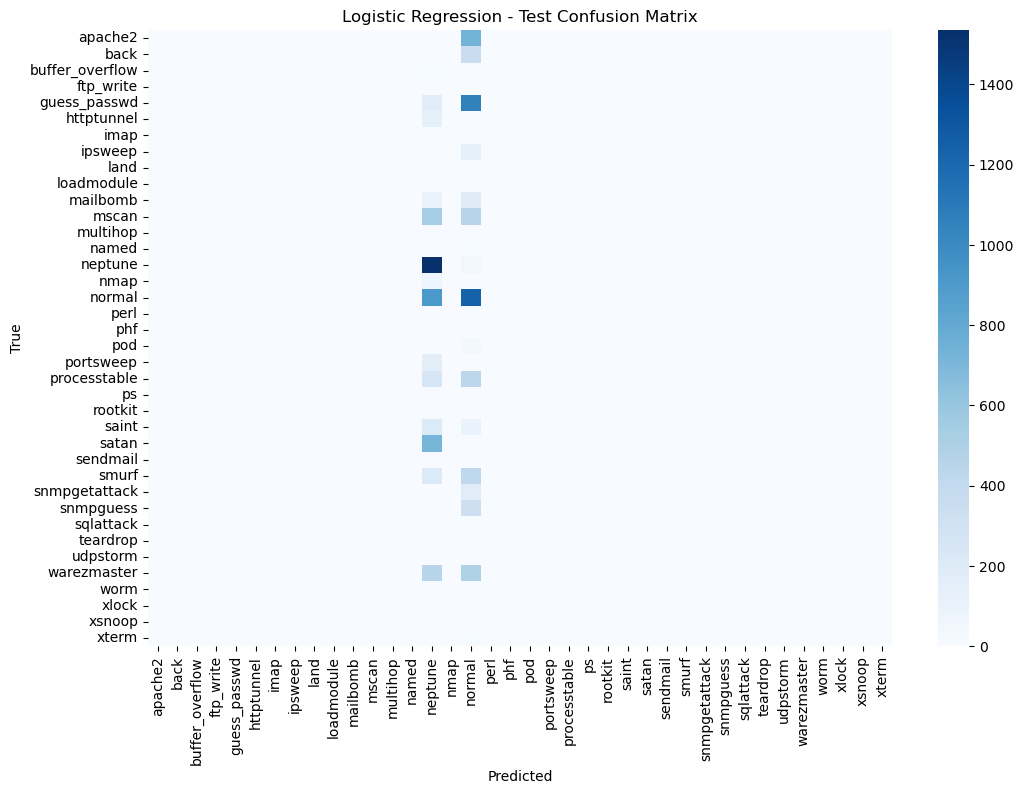


===== Random Forest =====
Validation Accuracy: 0.99857120177806
Validation Report:
                  precision    recall  f1-score   support

           back       0.99      1.00      0.99        96
buffer_overflow       1.00      1.00      1.00         3
      ftp_write       0.00      0.00      0.00         1
   guess_passwd       1.00      1.00      1.00         5
           imap       1.00      1.00      1.00         1
        ipsweep       1.00      1.00      1.00       360
           land       0.67      1.00      0.80         2
     loadmodule       0.00      0.00      0.00         1
       multihop       0.00      0.00      0.00         1
        neptune       1.00      1.00      1.00      4122
           nmap       0.99      0.99      0.99       149
         normal       1.00      1.00      1.00      6735
            pod       1.00      1.00      1.00        20
      portsweep       1.00      0.99      1.00       293
        rootkit       0.00      0.00      0.00         1
  

c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


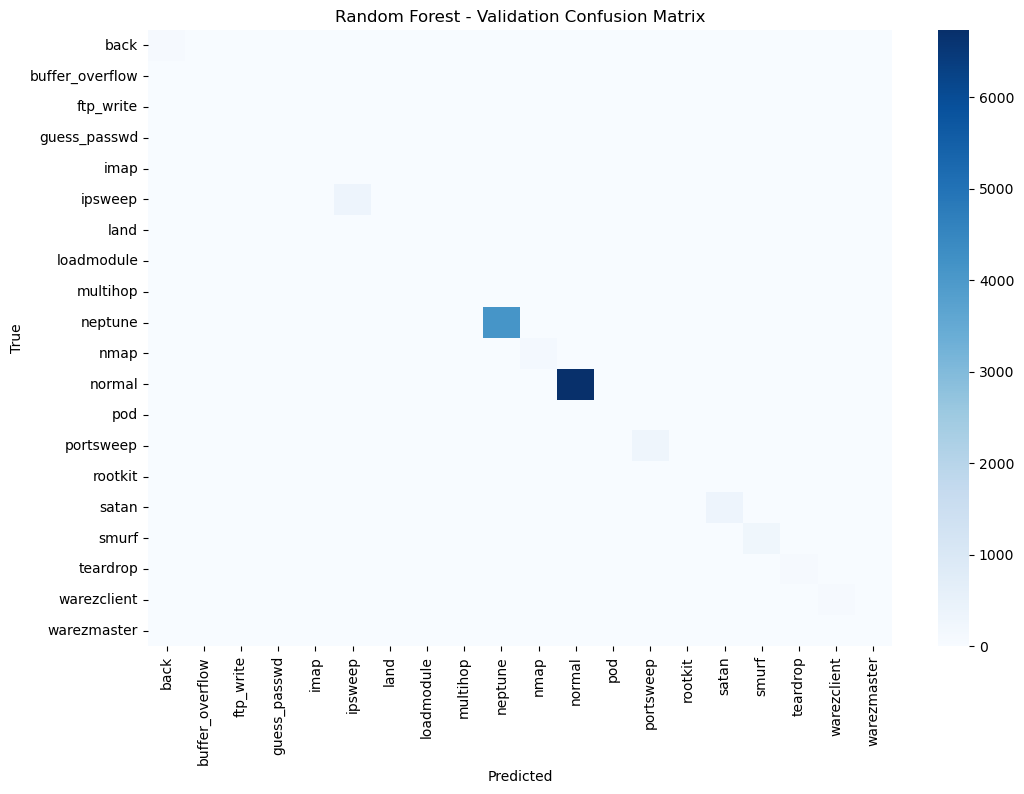

c:\Users\khush\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Test Accuracy: 0.37063291139240506
Test Report:
                  precision    recall  f1-score   support

        apache2       0.00      0.00      0.00       737
           back       0.00      0.00      0.00       359
buffer_overflow       0.00      0.00      0.00        20
      ftp_write       0.00      0.00      0.00         3
   guess_passwd       0.00      0.00      0.00      1231
     httptunnel       0.00      0.00      0.00       133
           imap       0.00      0.00      0.00         1
        ipsweep       0.19      0.99      0.32       141
           land       1.00      0.86      0.92         7
     loadmodule       0.00      0.00      0.00         2
       mailbomb       0.00      0.00      0.00       293
          mscan       0.00      0.00      0.00       996
       multihop       0.00      0.00      0.00        18
          named       0.00      0.00      0.00        17
        neptune       0.88      0.94      0.91      1579
           nmap       0.41      1.00  

c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


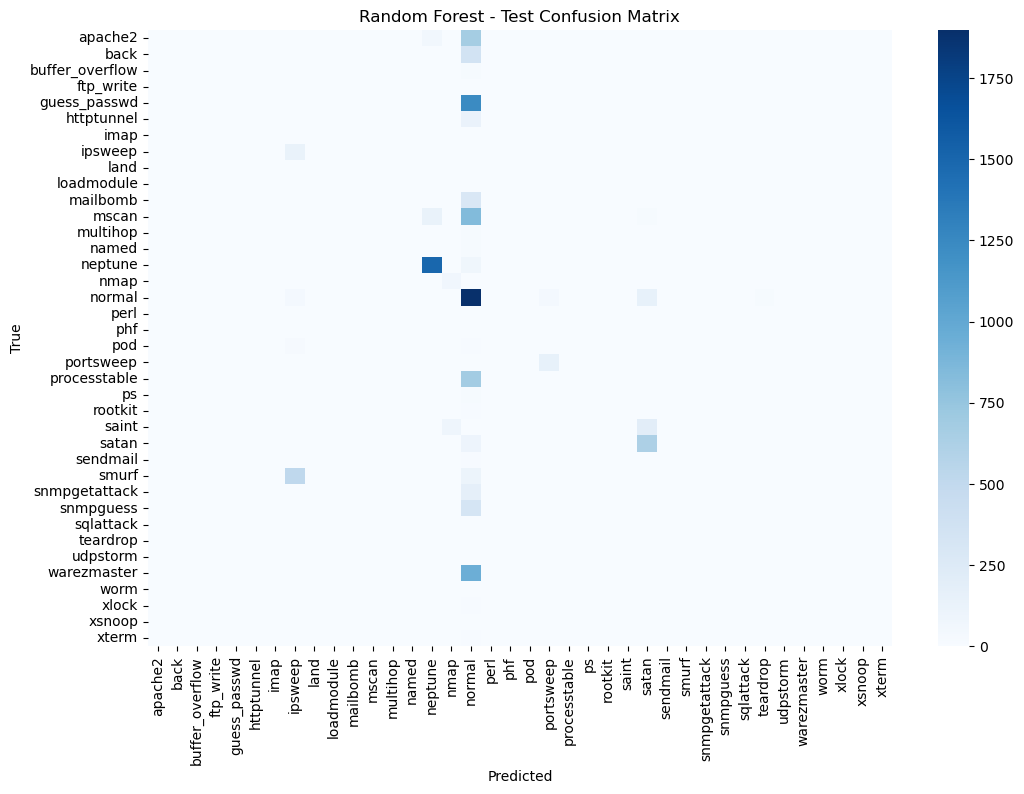


===== Linear SVM =====


c:\Users\khush\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted sam

Validation Accuracy: 0.9176059692014605
Validation Report:
                  precision    recall  f1-score   support

           back       0.00      0.00      0.00        96
buffer_overflow       0.00      0.00      0.00         3
      ftp_write       0.00      0.00      0.00         1
   guess_passwd       1.00      0.80      0.89         5
           imap       0.00      1.00      0.01         1
        ipsweep       0.97      0.97      0.97       360
           land       0.67      1.00      0.80         2
     loadmodule       0.00      0.00      0.00         1
       multihop       0.00      0.00      0.00         1
        neptune       1.00      0.99      1.00      4122
           nmap       0.27      0.92      0.42       149
         normal       0.98      0.94      0.96      6735
            pod       0.00      0.00      0.00        20
      portsweep       0.96      0.63      0.76       293
        rootkit       0.00      0.00      0.00         1
          satan       0.98 

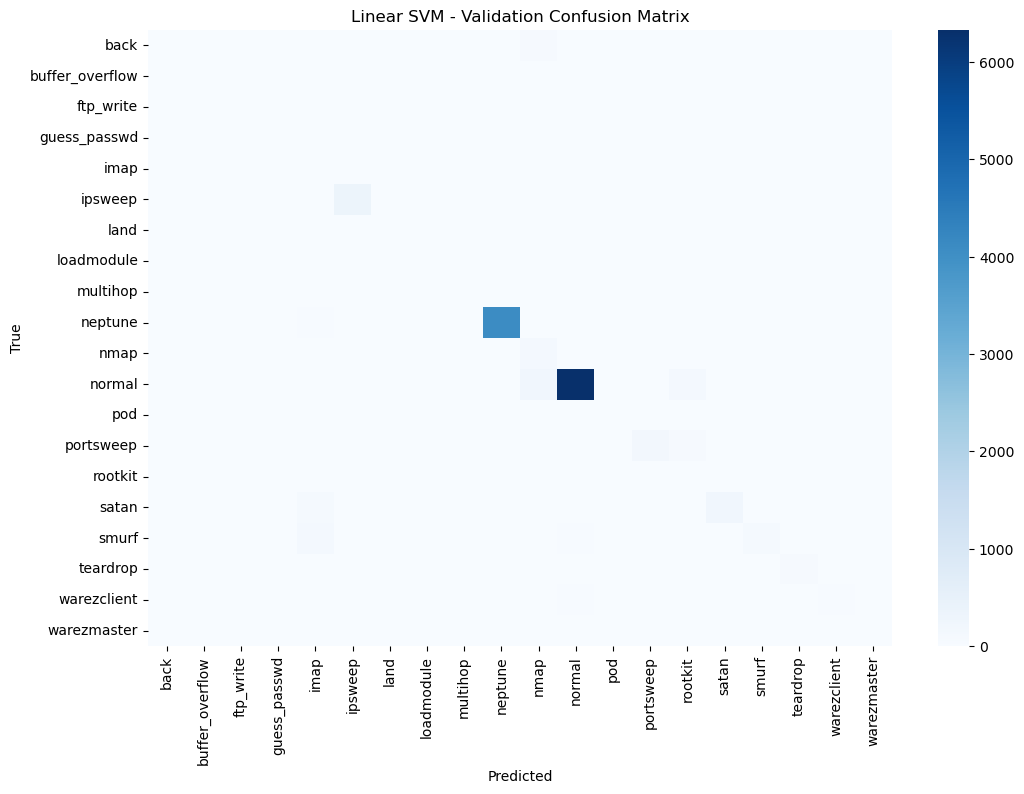

c:\Users\khush\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted 

Test Accuracy: 0.20405063291139242
Test Report:
                  precision    recall  f1-score   support

        apache2       0.00      0.00      0.00       737
           back       0.00      0.00      0.00       359
buffer_overflow       0.00      0.00      0.00        20
      ftp_write       0.00      0.33      0.00         3
   guess_passwd       0.00      0.00      0.00      1231
     httptunnel       0.00      0.00      0.00       133
           imap       0.00      0.00      0.00         1
        ipsweep       0.05      0.99      0.10       141
           land       0.02      0.86      0.03         7
     loadmodule       0.00      0.00      0.00         2
       mailbomb       0.00      0.00      0.00       293
          mscan       0.00      0.00      0.00       996
       multihop       0.00      0.00      0.00        18
          named       0.00      0.00      0.00        17
        neptune       0.73      0.53      0.61      1579
           nmap       0.14      0.99  

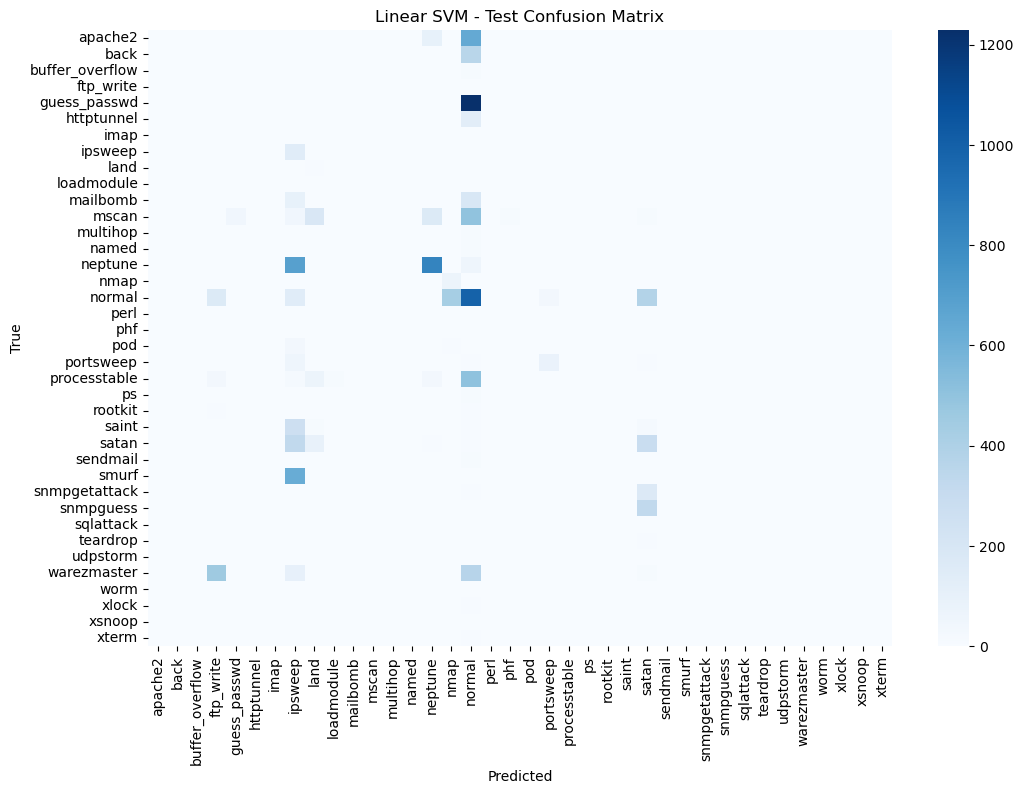

In [38]:
for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)

    # --- Validation Performance ---
    y_val_pred = model.predict(X_val)
    val_classes = np.unique(y_val)
    val_class_names = le.inverse_transform(val_classes).astype(str).tolist()

    print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
    print("Validation Report:\n",
          classification_report(y_val, y_val_pred, labels=val_classes, target_names=val_class_names))

    val_cm = confusion_matrix(y_val, y_val_pred, labels=val_classes)
    plt.figure(figsize=(12, 8))
    sns.heatmap(val_cm, cmap="Blues", xticklabels=val_class_names, yticklabels=val_class_names)
    plt.title(f"{name} - Validation Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # --- Test Performance ---
    y_test_pred = model.predict(X_test_final_scaled)
    test_classes = np.unique(y_test_final)
    test_class_names = le.inverse_transform(test_classes).astype(str).tolist()

    print("Test Accuracy:", accuracy_score(y_test_final, y_test_pred))
    print("Test Report:\n",
          classification_report(y_test_final, y_test_pred, labels=test_classes, target_names=test_class_names))

    test_cm = confusion_matrix(y_test_final, y_test_pred, labels=test_classes)
    plt.figure(figsize=(12, 8))
    sns.heatmap(test_cm, cmap="Blues", xticklabels=test_class_names, yticklabels=test_class_names)
    plt.title(f"{name} - Test Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()